# Earthquake Alert Prediction
## CSCI3360 Final Project - by Sach Shrestha

### Downloading Dataset from Kaggle using Kaggle API

The location of the downloaded dataset is stored in the path variable. I simply moved the dataset from the storage folder to the relevant project folder to begin.

In [104]:
# importing dataset:

# import kagglehub

# path = kagglehub.dataset_download("ahmeduzaki/earthquake-alert-prediction-dataset")
# print("Dataset located in: ", path)

Link to webpage: <https://www.kaggle.com/datasets/ahmeduzaki/earthquake-alert-prediction-dataset/data>

### Importing necessary packages

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

stdsc = StandardScaler()

### Importing Dataset and Exploring the Data

In [106]:
df = pd.read_csv("earthquake_alert_balanced_dataset.csv")
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


#### Details about each feature from the Dataset provider: 

| Feature | Description |
| --------| ------------|
| magnitude | The magnitude of the earthquake (Richter Scale) |
| depth | The depth where the earthquake begins to rupture (km) |
| cdi | The maximum reported intensity for the event range |
| mmi | The maximum estimated instrumental intensity for the event |
| sig | A comprehensive significance measure determined by multiple factors including magnitude, maximum MMI, felt reports, and estimated impact. Higher values indicate more significant seismic events |
| alert | Categorical earthquake alert level classification system (Target Variable) - “green”, “yellow”, “orange”, and “red”|

In [107]:
df.shape

(1300, 6)

Checking if dataset contains na/ null values:

In [108]:
df.isnull().sum()
# df.isna().sum()

magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

In [109]:
df.dtypes

magnitude    float64
depth        float64
cdi          float64
mmi          float64
sig          float64
alert         object
dtype: object

In [110]:
df.describe()

,magnitude,depth,cdi,mmi,sig
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,7.061008,50.321538,6.976154,6.939231,-9.749231
std,0.423738,104.348286,2.244875,1.354774,62.245214
min,6.500000,2.000000,0.000000,1.000000,-128.000000
25%,6.700000,12.000000,6.000000,6.000000,-54.000000
50%,7.000000,19.000000,8.000000,7.000000,-7.000000
75%,7.300000,38.000000,8.000000,8.000000,31.000000
max,8.600000,670.000000,9.000000,9.000000,127.000000


Different features are distributed differently, meaning we'll have to standard scale them before putting them into a covariance matrix.

Also, since alert is listed as an object data type, we will have to change that to categorical data for analysis.

In [111]:
alert_mapping = {'green':0.0, 'yellow':1.0, 'orange':2.0, 'red': 3.0}
df['alert_mapped'] = df['alert'].map(alert_mapping)
df.head()

,magnitude,depth,cdi,mmi,sig,alert,alert_mapped
0,7.0,14.0,8.0,7.0,0.0,green,0.0
1,6.9,25.0,4.0,4.0,-33.0,green,0.0
2,7.0,579.0,3.0,3.0,-13.0,green,0.0
3,7.3,37.0,5.0,5.0,65.0,green,0.0
4,6.6,624.0,0.0,2.0,-98.0,green,0.0


In [112]:
df['alert_mapped'].dtype

dtype('float64')

Now, dropping the alert column as it is an object data type, which will interfere with further analysis and modeling.

In [113]:
df = df.drop(columns='alert')

Now analysing plots of the dataset before transforming dataset for processing:

### Histogram of Earthquake Magnitudes

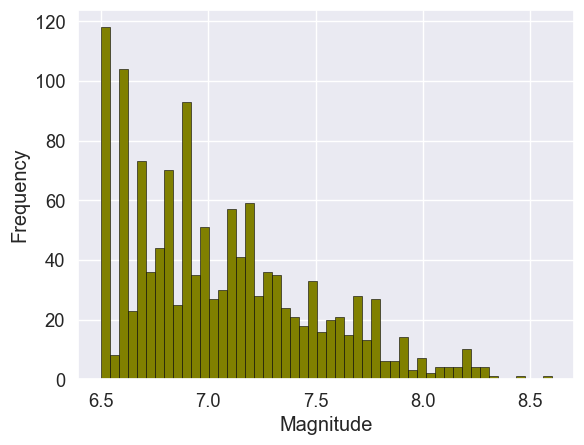

In [114]:
plt.hist(df['magnitude'], bins=50, color='olive', edgecolor='black', linewidth=0.4)
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

As we can see from the right skewed histogram above, smaller magnitude earthquakes are more frequent. 

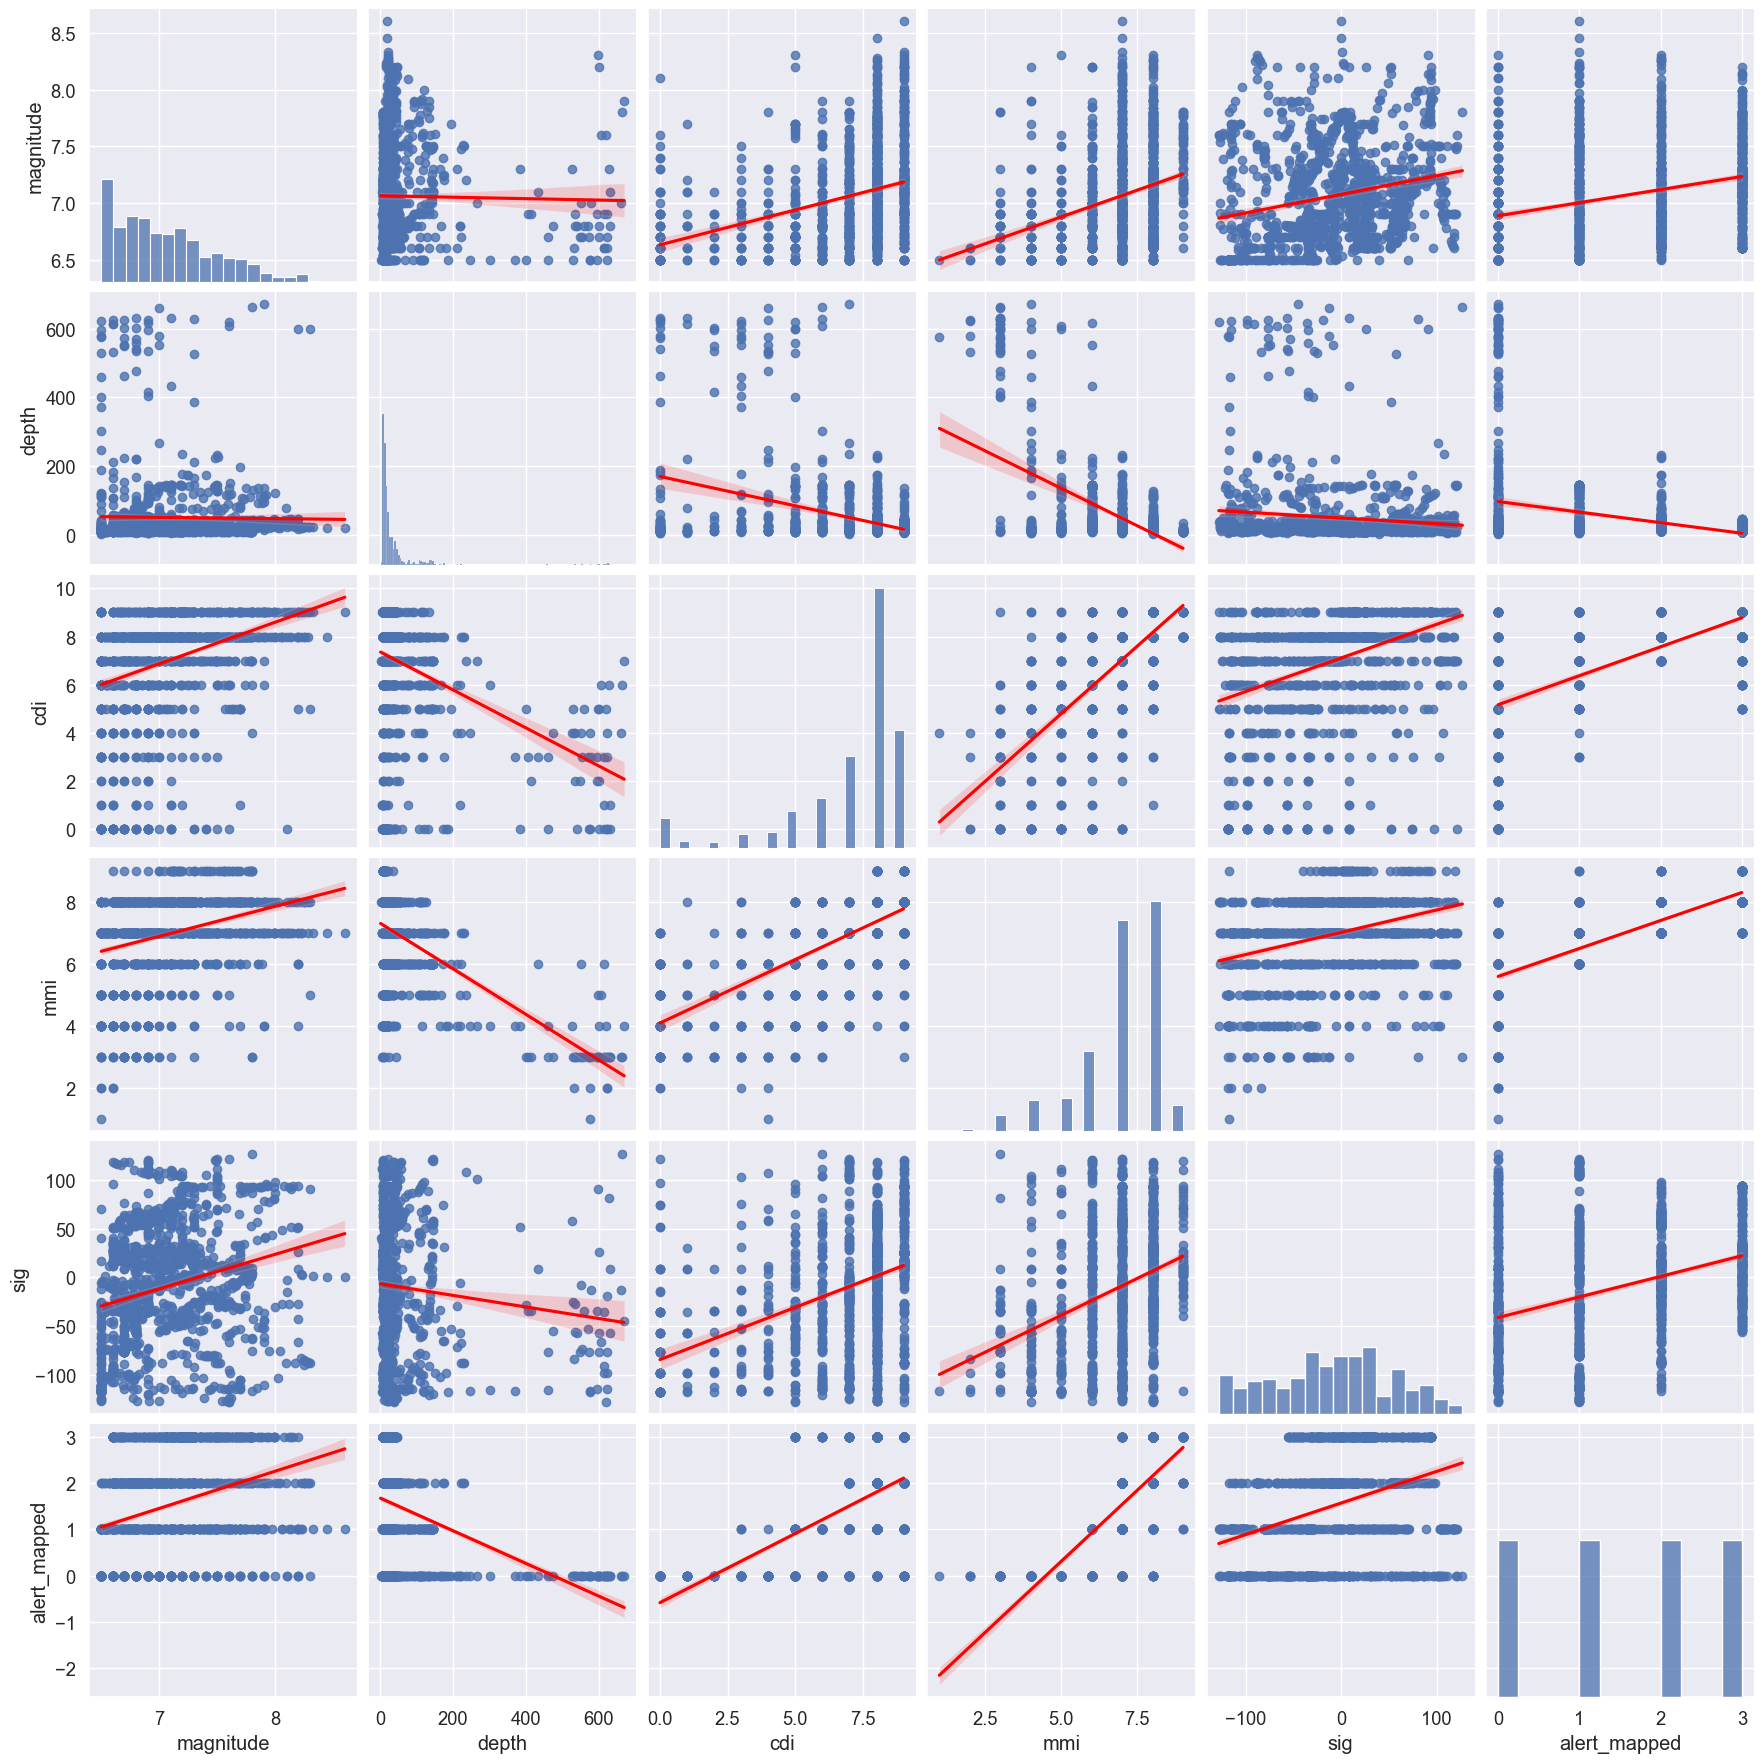

In [115]:
# Histogram of eq magnitudes
# sns pairplot 
# sns correlation matrix

sns.pairplot(df, height=3.0, kind='reg', plot_kws = {'line_kws':{'color':'red'}}, aspect=1.0)
plt.show() 

In [116]:
x_cols = df.columns[0:6]
X_cov = stdsc.fit_transform(df.iloc[:,range(0,6)].values)
X_std = stdsc.fit_transform(df.iloc[:,range(0,5)].values)
X = df.iloc[:,range(0,5)].values

y = df['alert_mapped'].values.reshape(-1,1)

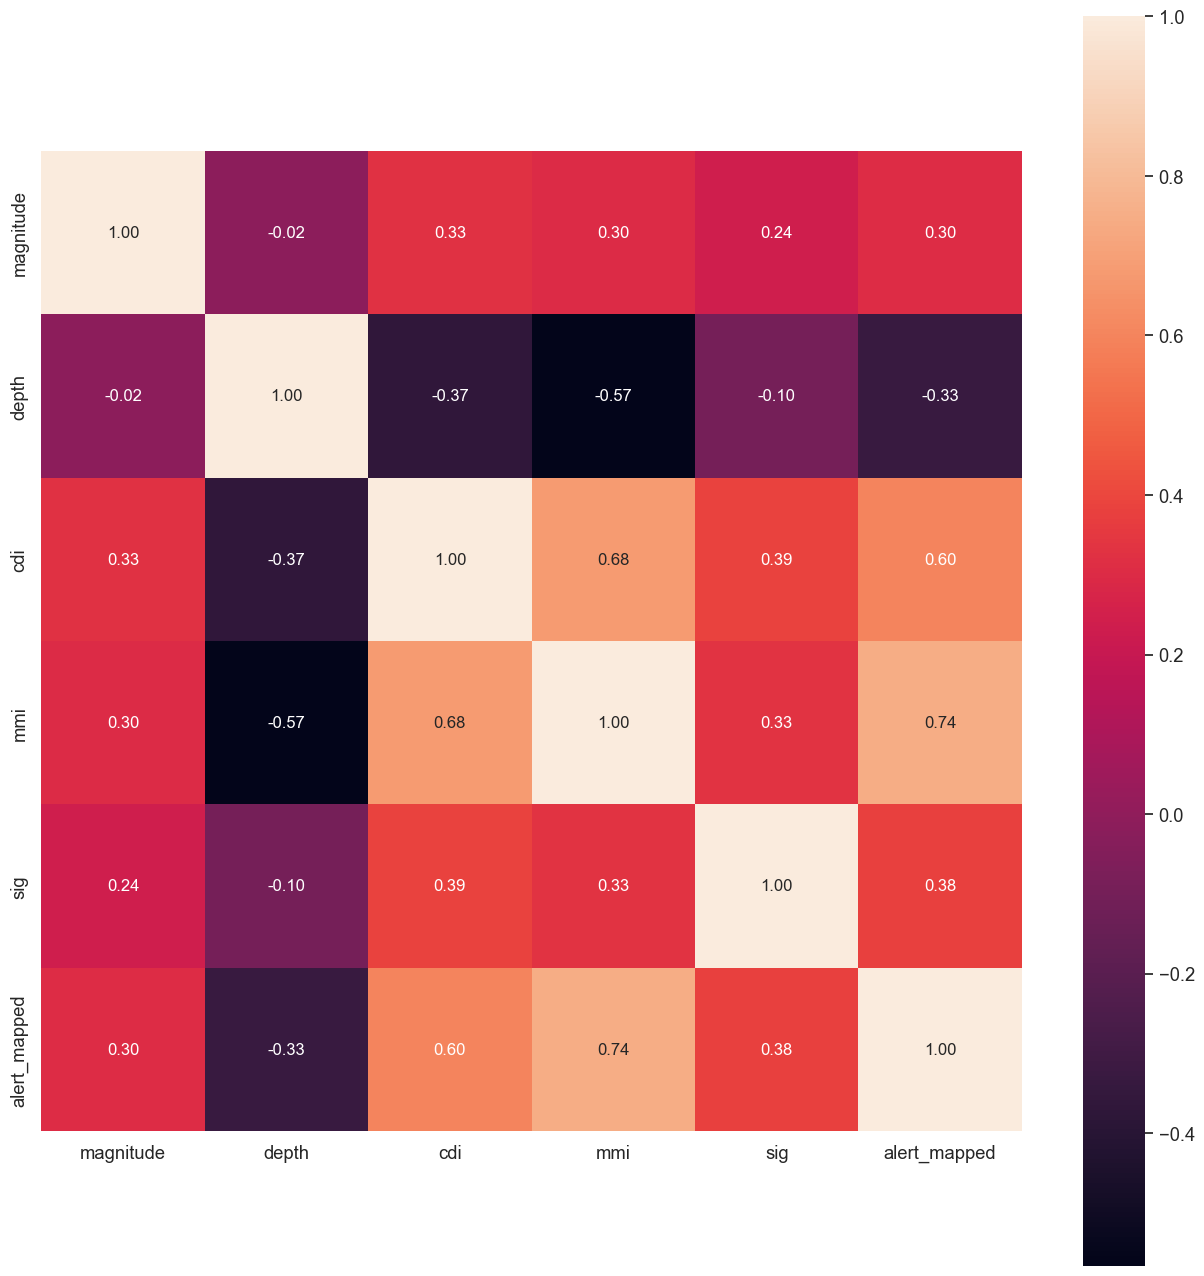

In [117]:
cov_mat = np.cov(X_cov.T, bias=True)

plt.figure(figsize=(13,13))
sns.set(font_scale=1.2)
hm = sns.heatmap(cov_mat,
                 cbar=True,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 12},
                 yticklabels=x_cols,
                 xticklabels=x_cols)
plt.tight_layout()
plt.show()


### Splitting dataset into train-test sets (3:1)

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 257, stratify=y)

### Implementing Decision Tree for Multi-class Classification:

In [119]:
class Node():
  def __init__(self, feature=None, threshold=None, left=None, right=None, gain=None, value=None):
    self.feature = feature
    self.threshold = threshold
    self.left = left
    self.right = right
    self.gain = gain
    self.value = value

In [120]:
# Decision Tree based on entropy splitting criterion
# Adapted from Decision Tree code I used in a previous assignment for this course:

class DecisionTree():
  def __init__(self, min_samples=2,max_depth=4):
    self.min_samples = min_samples
    self.max_depth = max_depth

  def split_data(self, dataset, feature, threshold):
    left_dataset = []
    right_dataset = []
    for row in dataset:
      if row[feature] <= threshold:
        left_dataset.append(row)
      else:
        right_dataset.append(row)
    return np.array(left_dataset), np.array(right_dataset)

  def entropy(self, y):
    entropy = 0
    labels = np.unique(y)
    for label in labels:
      label_e = y[y == label]
      p = len(label_e)/len(y)
      entropy += -p * np.log2(p)
    return entropy

  def information_gain(self, parent, left, right):
    information_gain = 0
    parent_entropy = self.entropy(parent)
    weight_left = len(left) / len(parent)
    weight_right= len(right) / len(parent)
    entropy_left, entropy_right = self.entropy(left), self.entropy(right)
    weighted_entropy = weight_left * entropy_left + weight_right * entropy_right
    information_gain = parent_entropy - weighted_entropy
    return information_gain

  def best_split(self, dataset, num_samples, num_features):
    best_split = {'gain':-1, 'feature': None, 'threshold': None}
    for feature_index in range(num_features):
      feature_values = dataset[:, feature_index]
      thresholds = np.unique(feature_values)
      for threshold in thresholds:
        left_dataset, right_dataset = self.split_data(dataset, feature_index, threshold)
        if len(left_dataset) and len(right_dataset):
          y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
          information_gain = self.information_gain(y, left_y, right_y)
          if information_gain > best_split["gain"]:
            best_split["feature"] = feature_index
            best_split["threshold"] = threshold
            best_split["left_dataset"] = left_dataset
            best_split["right_dataset"] = right_dataset
            best_split["gain"] = information_gain
    return best_split

  def calculate_leaf_value(self, y):
    y = list(y)
    most_occuring_value = max(y, key=y.count)
    return most_occuring_value

  def build_tree(self, dataset, current_depth=0):
    X, y = dataset[:, :-1], dataset[:, -1]
    n_samples, n_features = X.shape
    if n_samples >= self.min_samples and current_depth <= self.max_depth:
      best_split = self.best_split(dataset, n_samples, n_features)
      if best_split["gain"] and len(best_split) == 5:
        left_node = self.build_tree(best_split["left_dataset"], current_depth+1)
        right_node = self.build_tree(best_split["right_dataset"], current_depth+1)
        return Node(best_split["feature"], best_split["threshold"], left_node, right_node, best_split["gain"])
    leaf_value = self.calculate_leaf_value(y)
    return Node(value=leaf_value)

  def fit(self, X, y):
    dataset = np.concatenate((X,y), axis=1)
    self.root = self.build_tree(dataset)

  def predict(self, X):
    preds = []
    for x in X:
      pred = self.make_prediction(x, self.root)
      preds.append(pred)
    return np.array(preds)

  def make_prediction(self, x, node):
    if node.value != None:
      return node.value
    else:
      feature = x[node.feature]
      if feature <= node.threshold:
        return self.make_prediction(x, node.left)
      else:
        return self.make_prediction(x, node.right)


In [121]:
def accuracy(y_true, y_pred):
  y_true = y_true.flatten()
  total_samples = len(y_true)
  correct_predictions = np.sum(y_true == y_pred)
  return (correct_predictions / total_samples)

In [122]:
model = DecisionTree()

model.fit(X_train, y_train)

In [123]:
predictions = model.predict(X_test)

In [124]:
train_preds = model.predict(X_train)

In [125]:
# training accuracy
print(f"Model's Accuracy: {accuracy(y_train, train_preds)}")

Model's Accuracy: 0.7856410256410257


In [126]:
# testing accuracy
print(f"Model's Accuracy: {accuracy(y_test, predictions)}")

Model's Accuracy: 0.7169230769230769


In [127]:
print('Example using test datapoint 167:\n')
print(f"Actual Alert: {y_test.flatten()[167]}\nPredicted Alert: {predictions[167]}")

Example using test datapoint 167:

Actual Alert: 3.0
Predicted Alert: 3.0


### Finding the ideal max depth (hyperparam) for the Decision Tree to maximize train-test accuracy:

In [128]:
# Note: This can take a minute to run

train_acc = []
test_acc = [] 

for i in range(20):
  model = DecisionTree(max_depth=i, min_samples=2)
  model.fit(X_train, y_train)
  train_pr = model.predict(X_train)
  test_pr = model.predict(X_test)
  train_acc.append(accuracy(y_train, train_pr))
  test_acc.append(accuracy(y_test, test_pr))

In [129]:
test_acc.index(max(test_acc))

13

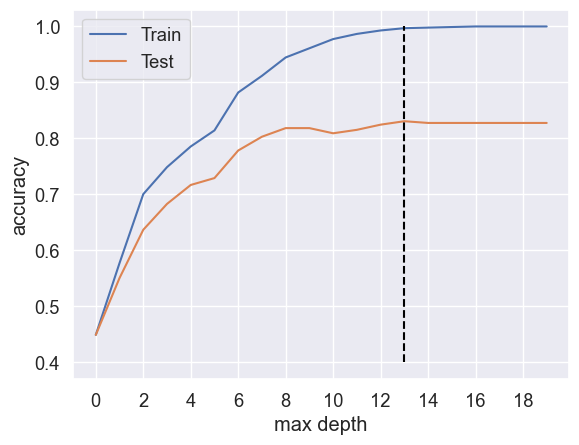

In [130]:
plt.plot(train_acc)
plt.plot(test_acc)
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.xticks(np.arange(0, 20, 2))
plt.legend(['Train', 'Test'])
plt.vlines(x=13, ymin=0.4, ymax=1.0, linestyles='--', color='black')
plt.show()

In [131]:
print(f'At Max Depth = 13: training accuracy = {(train_acc[13]*100).round(1)}%, testing accuracy = {(test_acc[13]*100).round(1)}%')

At Max Depth = 13: training accuracy = 99.7%, testing accuracy = 83.1%


We can see both training and testing accuracy increase with the max depth of model. However, as the tree gets deeper, it gets more complex and as such can be prone to overfitting to training data. We can see that the testing accuracy reaches its peak at max_depth = 13, and dips slightly after that and stagnates, while the training accuracy stabilizes at 100%. This suggests the model might be overfitting past depth of 13.

This is the best performance we can get out of this base Decision Tree. To improve this model further, we would have to implement an ensemble method that utilizes this decision tree model. One such method is Random Forest using Bagging (Bootstrap Aggregating). The main idea behind this approach is to create a forest of decision trees each with a bootstrap aggregated sample, then using the mode classification label gathered from all the trees in the forest as the final classification. This creates a model robust to outliers and overfitting.

### Implementing Random Forest:

In [132]:
from collections import Counter

class RandomForest:
  def __init__(self, n_estimators=10, max_depth=4, min_samples=2, random_state=257):
    self.n_estimators = n_estimators
    self.max_depth = max_depth
    self.min_samples = min_samples
    self.rng = np.random.default_rng(random_state)

  def fit(self, X, y):
    self.trees = []
    for _ in range(self.n_estimators):
      tree = DecisionTree(max_depth=self.max_depth,min_samples=self.min_samples)
      X_sample, y_sample = self.bootstrap_samples(X, y)
      tree.fit(X_sample, y_sample)
      self.trees.append(tree)

  def bootstrap_samples(self, X, y):
    n_samples = X.shape[0]
    indices = self.rng.choice(n_samples, n_samples, replace=True)
    return X[indices], y[indices]
  
  def final_label(self, y):
    counter = Counter(y)
    most_common = counter.most_common(1)[0][0] # the most common predicted label
    return most_common
  
  def predict(self, X):
    preds = np.array([tree.predict(X) for tree in self.trees])
    tree_preds = preds.T
    preds = np.array([self.final_label(pred) for pred in tree_preds])
    return preds

### Testing Random Forest Classifier

First, using n_estimators = 10, a.k.a using 10 Decision Trees in the ensemble. Using max_depth of 13 to keep it consistent with the best performing Decision Tree model. Also, the random_state is set to 42, which is different from the default of 257.

In [133]:
rfc = RandomForest(n_estimators=10, max_depth=13, random_state=42)
rfc.fit(X_train, y_train)

In [134]:
train_rfc = rfc.predict(X_train)
test_rfc = rfc.predict(X_test)

In [135]:
# training accuracy
print(f"Model's Accuracy: {accuracy(y_train, train_rfc)}")

Model's Accuracy: 0.9856410256410256


In [136]:
# testing accuracy
print(f"Model's Accuracy: {accuracy(y_test, test_rfc)}")

Model's Accuracy: 0.8646153846153846


We get around ~1% lower training accuracy, but ~5% better testing accuracy. This shows that the ensemble random forest model is robust to overfitting to the training data. 

### Now trying to find the best n_estimator (hyperparam):

In [ ]:
# Note: This can take a few minutes to run

train_acc_rfc = []
test_acc_rfc = []

n_vals = [10, 50, 100, 200]

for i in n_vals:
  rfc = RandomForest(n_estimators=i, max_depth=13, random_state=42)
  rfc.fit(X_train, y_train)
  train_pr = rfc.predict(X_train)
  test_pr = rfc.predict(X_test)
  train_acc_rfc.append(accuracy(y_train, train_pr))
  test_acc_rfc.append(accuracy(y_test, test_pr))

In [ ]:
test_acc_rfc.index(max(test_acc_rfc))

3

In [ ]:
test_acc_rfc

[0.8646153846153846, 0.88, 0.8830769230769231, 0.8923076923076924]

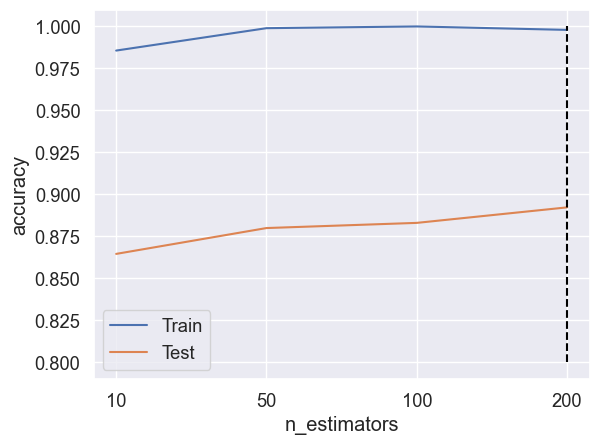

In [ ]:
plt.plot(train_acc_rfc)
plt.plot(test_acc_rfc)
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.legend(['Train', 'Test'])
plt.xticks([0,1,2,3], [10, 50, 100, 200])
plt.vlines(x=3, ymin=0.80, ymax=1.0, linestyles='--', color='black')
plt.show()

In [ ]:
print(f'At n_estimators = 200: training accuracy = {(train_acc_rfc[3]*100).round(1)}%, testing accuracy = {(test_acc_rfc[3]*100).round(1)}%')

At n_estimators = 200: training accuracy = 99.8%, testing accuracy = 89.2%


Looking at the train-test accuracy graph, we can see there is a trend upwards for test accuracy with higher number of decision trees in the forest (higher n_estimators). However, going higher will take a bigger computational load. Then, there is the case of how much computational load you're willing to put up with for a very slight increase in accuracy. As such, I will settle at n_estimators = 200. 

n_estimators = 50 is also a good threshold as it has the steepest increase and relatively lower number of decision trees involved in computation.

### Next comparing it to other baseline models

In [191]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

xtrain, xtest, ytrain, ytest = train_test_split(X_std, y.flatten(), test_size=0.25, random_state = 257, stratify=y)

lm = LogisticRegression(solver='lbfgs', max_iter=200)
lm.fit(xtrain, ytrain)
y_pred_lm = lm.predict(xtest)
y_pred_lm2 = lm.predict(xtrain)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(xtrain, ytrain)
y_pred_knn = knn.predict(xtest)
y_pred_knn2 = knn.predict(xtrain)

svm = SVC(decision_function_shape='ovo', kernel='rbf', C=1.0, gamma='scale')
svm.fit(xtrain, ytrain)
y_pred_svm = svm.predict(xtest)
y_pred_svm2 = svm.predict(xtrain)

In [192]:
print("---Logistic Regression Model---")
print(f'Training: {round(accuracy_score(ytrain, y_pred_lm2)*100,1)}')
print(f'Testing: {round(accuracy_score(ytest, y_pred_lm)*100,1)}')


---Logistic Regression Model---
Training: 65.5
Testing: 68.0


In [193]:
print("---KNN Model---")
print(f'Training: {round(accuracy_score(ytrain, y_pred_knn2)*100,1)}')
print(f'Testing: {round(accuracy_score(ytest, y_pred_knn)*100,1)}')

---KNN Model---
Training: 91.6
Testing: 84.9


In [194]:
print("---SVM Model---")
print(f'Training: {round(accuracy_score(ytrain, y_pred_svm2)*100,1)}')
print(f'Testing: {round(accuracy_score(ytest, y_pred_svm)*100,1)}')

---SVM Model---
Training: 77.8
Testing: 72.9


For presentation demo:

In [2]:
# Takes ~10-30s

demo = RandomForest(n_estimators=10, max_depth=13, random_state=42)
demo.fit(X_train, y_train)
train_demo = demo.predict(X_train)
test_demo = demo.predict(X_test)
training_accuracy = accuracy(y_train, train_demo)
testing_accuracy = accuracy(y_test, test_demo)

print(f'training accuracy = {(training_accuracy*100).round(1)}% \ntesting accuracy = {(testing_accuracy*100).round(1)}%')

NameError: name 'RandomForest' is not defined

In [196]:
df.describe()

,magnitude,depth,cdi,mmi,sig,alert_mapped
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,7.061008,50.321538,6.976154,6.939231,-9.749231,1.500000
std,0.423738,104.348286,2.244875,1.354774,62.245214,1.118464
min,6.500000,2.000000,0.000000,1.000000,-128.000000,0.000000
25%,6.700000,12.000000,6.000000,6.000000,-54.000000,0.750000
50%,7.000000,19.000000,8.000000,7.000000,-7.000000,1.500000
75%,7.300000,38.000000,8.000000,8.000000,31.000000,2.250000
max,8.600000,670.000000,9.000000,9.000000,127.000000,3.000000


In [1]:
x_entry = [[8.6,
            20.0,
            9.0,
            9.0,
            -20.0
]]

alert_lvl = demo.predict(x_entry)[0]

match alert_lvl:
  case 0.0:
    print('Alert: Green')
  case 1.0:
    print('Alert: Yellow')
  case 2.0:
    print('Alert: Orange')
  case 3.0:
    print('Alert: Red')

NameError: name 'demo' is not defined